In [1]:
from astropy.io import fits

hdul = fits.open("/path/to/rgc/duplicate_pair_check/fits/g1_a_Lao.fits")
print(hdul[0].header["CDELT1"])
print(hdul[0].header["CDELT2"])

-0.0005
0.0005


In [2]:
import legacystamps

# Define your target coordinates
ra = 0.296667  # Right Ascension in degrees
dec = -0.336556   # Declination in degrees
size = 0.075  # Cutout size in arcseconds

# 1. To download an RGB JPEG cutout
legacystamps.download(ra=ra, dec=dec, mode='jpeg', bands='grz', size=size)

# 2. To download a multi-band FITS cutout (used for scientific data)
# Note: You can specify particular bands like 'g', 'r', or 'z', or 'grz' for all
legacystamps.download(ra=ra, dec=dec, mode='fits', bands='grz', size=size)


URL to obtain cutout: https://www.legacysurvey.org/viewer/jpeg-cutout/?ra=0.296667&dec=-0.336556&layer=ls-dr9&pixscale=0.262&bands=grz&size=1030
Download directory not specified, downloading to /path/to/rgc/notebooks instead.
324KB [00:01, 233.80KB/s]                         
Cutout saved to /path/to/rgc/notebooks/legacystamps_0.296667_-0.336556_ls-dr9.jpeg.
URL to obtain cutout: https://www.legacysurvey.org/viewer/fits-cutout/?ra=0.296667&dec=-0.336556&layer=ls-dr9&pixscale=0.262&bands=grz&size=1030
Download directory not specified, downloading to /path/to/rgc/notebooks instead.
12437KB [00:02, 4466.78KB/s]                          
Cutout saved to /path/to/rgc/notebooks/legacystamps_0.296667_-0.336556_ls-dr9.fits.


'/path/to/rgc/notebooks/legacystamps_0.296667_-0.336556_ls-dr9.fits'

In [3]:
from astropy.wcs import WCS
from astropy.io import fits
import numpy as np

hdr = fits.getheader("/path/to/rgc/notebooks/legacystamps_0.296667_-0.336556_ls-dr9.fits")

wcs = WCS(hdr)

# degrees per pixel
pixscale_x = np.sqrt(wcs.pixel_scale_matrix[0,0]**2 +
                     wcs.pixel_scale_matrix[0,1]**2)

pixscale_y = np.sqrt(wcs.pixel_scale_matrix[1,0]**2 +
                     wcs.pixel_scale_matrix[1,1]**2)

print("deg/pixel:", pixscale_x, pixscale_y)
print("arcsec/pixel:", pixscale_x*3600, pixscale_y*3600)

deg/pixel: 7.27777777777778e-05 7.27777777777778e-05
arcsec/pixel: 0.26200000000000007 0.26200000000000007


 [astropy.io.fits.verify]


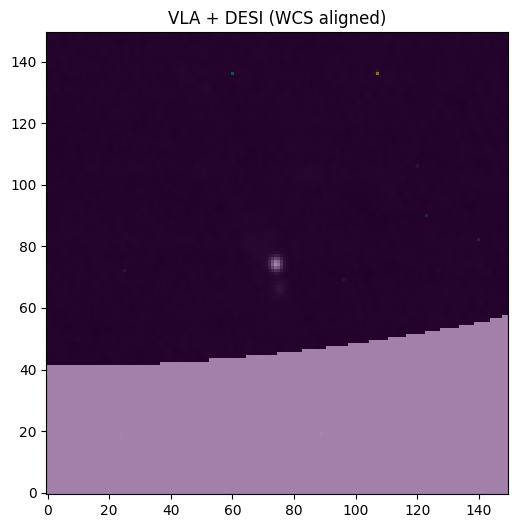

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from reproject import reproject_interp
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import make_lupton_rgb

# --- Load data
vla_hdu = fits.open("/path/to/rgc/Data/master_radio_catalog/fits/4_Lao.fits")[0]
desi_hdu = fits.open("/path/to/rgc/notebooks/legacystamps_0.296667_-0.336556_ls-dr9.fits")[0]

# --- Extract DESI cube (3, ny, nx)
desi_cube = np.squeeze(desi_hdu.data)

# --- Split bands
g, r, z = desi_cube

# --- Make RGB (for visualization only)
rgb = make_lupton_rgb(r, g, z, stretch=2, Q=10)

# --- Use r-band for scientific alignment (IMPORTANT)
desi_r = r

# --- Build 2D FITS for reprojection
desi_2d_hdu = fits.PrimaryHDU(data=desi_r, header=desi_hdu.header)

# --- WCS from VLA
vla_wcs = WCS(vla_hdu.header)

# --- Match shape exactly to radio image
shape_out = vla_hdu.data.shape

# --- Reproject DESI r-band onto VLA grid
desi_reproj, footprint = reproject_interp(
    desi_2d_hdu,
    vla_wcs,
    shape_out=shape_out
)

# --- Plot overlay
plt.figure(figsize=(6, 6))

plt.imshow(vla_hdu.data, cmap='gray', origin='lower')
plt.imshow(desi_reproj, alpha=0.5, origin='lower')

plt.title("VLA + DESI (WCS aligned)")
plt.show()

In [5]:
from astropy.io import fits

hdul = fits.open("/path/to/rgc/duplicate_pair_check/fits/g1_a_Lao.fits")
print(hdul[0].header["CDELT1"])
print(hdul[0].header["CDELT2"])

-0.0005
0.0005


In [6]:
from astroquery.ipac.irsa import Irsa

Irsa.list_catalogs(filter='wise')

{'quaia': 'Quaia: The Gaia-unWISE Quasar Catalog',
 'madcows2': 'Massive and Distant Clusters of WISE Survey 2 Catalog',
 'wisegalhii': 'WISE Catalog of Galactic HII Regions v2.2',
 'allwise_p3as_psd': 'AllWISE Source Catalog',
 'allwise_p3as_mep': 'AllWISE Multiepoch Photometry Table',
 'allwise_p3as_psr': 'AllWISE Reject Table',
 'allwise_p3as_cdd': 'AllWISE Atlas Metadata Table',
 'neowiser_p1bs_psd': 'NEOWISE-R Single Exposure (L1b) Source Table',
 'neowiser_p1ba_mch': "NEOWISE-R Known Solar System Object Possible Association List (<a href='http://wise2.ipac.caltech.edu/docs/release/neowise/expsup/kssopal.README.html' target='doc'> Caution </a>)",
 'neowiser_p1bs_frm': 'NEOWISE-R Single Exposure (L1b) Frame Metadata Table',
 'allsky_4band_p3as_psd': 'WISE All-Sky Source Catalog',
 'allsky_4band_p1bs_psd': 'WISE All-Sky Single Exposure (L1b) Source Table',
 'allsky_4band_p1ba_mch': "WISE All-Sky Known Solar System Object Possible Association List (<a href='http://wise2.ipac.caltech.

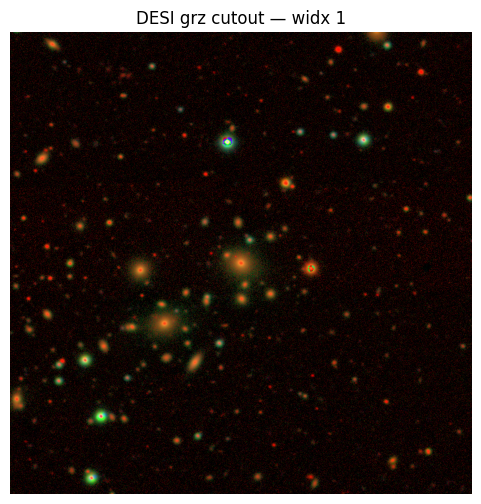

In [1]:
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
import numpy as np
import matplotlib.pyplot as plt
vla_image = "/path/to/rgc/Data/master_radio_catalog/fits/834_Mirabest.fits"
desi_image = "/path/to/rgc/Data/checking_all_row_DESI_host_cutouts/fits/834_desi.fits"

hdul = fits.open(desi_image)
desi_hdu = hdul[0]                       # PrimaryHDU holds the cube

# --- Extract DESI cube (3, ny, nx) and split bands (order = grz)
desi_cube = np.squeeze(desi_hdu.data)
g, r, z = desi_cube

# --- RGB: R=z (reddest), G=r, B=g (bluest) — conventional Legacy Survey mapping
rgb = make_lupton_rgb(z, r, g, stretch=0.08, Q=10)


plt.figure(figsize=(6, 6))
plt.imshow(rgb, origin="lower")
plt.title("DESI grz cutout — widx 1")
plt.axis("off")
plt.show()

# --- r-band kept for scientific alignment / reprojection
desi_r = r
desi_2d_hdu = fits.PrimaryHDU(data=desi_r, header=desi_hdu.header)

 [astropy.io.fits.verify]


sigma = 9.21e-04 Jy/beam   levels = [0.00276208 0.00552416 0.01104833 0.02209665 0.0441933  0.0883866
 0.17677321 0.35354641]


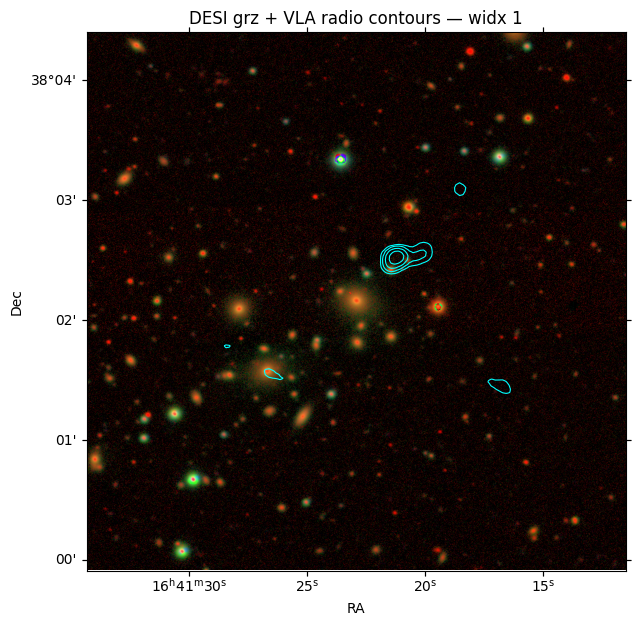

In [2]:
# --- Overlay VLA radio contours on the DESI grz RGB ---
from reproject import reproject_interp
from astropy.wcs import WCS

# Radio image (2D, JY/BEAM)
vla_hdu = fits.open(vla_image)[0]
vla_data = np.squeeze(vla_hdu.data)
vla_wcs = WCS(vla_hdu.header)

# DESI celestial WCS (drop the band axis from the 3D cube header)
desi_wcs = WCS(desi_hdu.header).celestial

# Reproject radio onto the DESI pixel grid so contours line up with the RGB
radio_reproj, _ = reproject_interp(
    (vla_data, vla_wcs),
    desi_wcs,
    shape_out=desi_r.shape,
)

# Contour levels from the noise: 3, 6, 12, ... sigma
sigma = np.nanstd(vla_data)
levels = sigma * 3 * 2 ** np.arange(8)
print(f"sigma = {sigma:.2e} Jy/beam   levels = {levels}")

# Plot RGB + radio contours (WCS axes)
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(projection=desi_wcs)
ax.imshow(rgb, origin="lower")
ax.contour(radio_reproj, levels=levels, colors="cyan", linewidths=0.8)
ax.set_title("DESI grz + VLA radio contours — widx 1")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()
